In [2]:
import sys
import numpy as np

print("Python Version:", sys.version)
print("NumPy Version:", np.__version__)

Python Version: 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
NumPy Version: 1.26.4


In [2]:

import pystac

url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

collection = pystac.Collection.from_file(url)

items = collection.get_items()
item = next(items)

print("Item ID:", item.id)


for key, asset in item.assets.items():
    print(key)
    

Item ID: CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453
HH
metadata
preview
thumbnail


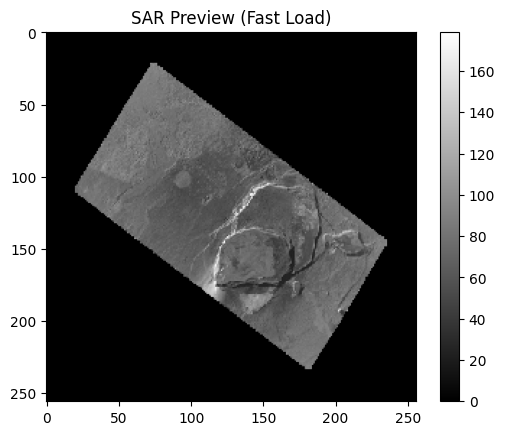

In [3]:
  
import os
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

import os
import rasterio
import matplotlib.pyplot as plt

os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

preview_url = item.assets['preview'].href

with rasterio.open(preview_url) as src:
    img = src.read(1, out_shape=(1, 256, 256))  # fast load

plt.imshow(img, cmap='gray')
plt.title("SAR Preview (Fast Load)")
plt.colorbar()
plt.show()

In [4]:
import os
import pystac
import rasterio
import numpy as np

# Important for AWS access
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

# STAC URL
url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

# Load collection
collection = pystac.Collection.from_file(url)

items = collection.get_items()

images = []
count = 0

for item in items:
    try:
        # Get preview image URL
        preview_url = item.assets['preview'].href
        
        # Load image (fast + resized)
        with rasterio.open(preview_url) as src:
            img = src.read(1, out_shape=(1, 256, 256))
        
        images.append(img)
        count += 1
        
        print(f"Loaded image {count}")
        
        # Stop after 10 images
        if count == 10:
            break
            
    except Exception as e:
        print("Skipped one image")
        continue

# Convert to numpy array
images = np.array(images)

print("Final shape:", images.shape)

Loaded image 1
Loaded image 2
Loaded image 3
Loaded image 4
Loaded image 5
Loaded image 6
Loaded image 7
Loaded image 8
Loaded image 9
Loaded image 10
Final shape: (10, 256, 256)


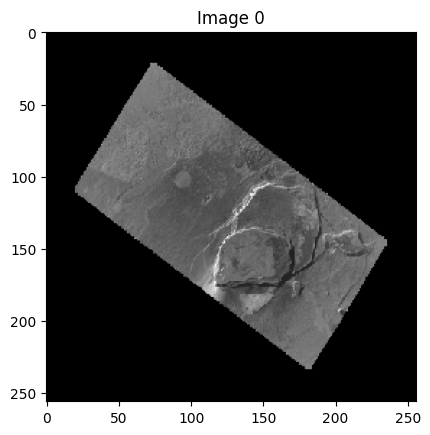

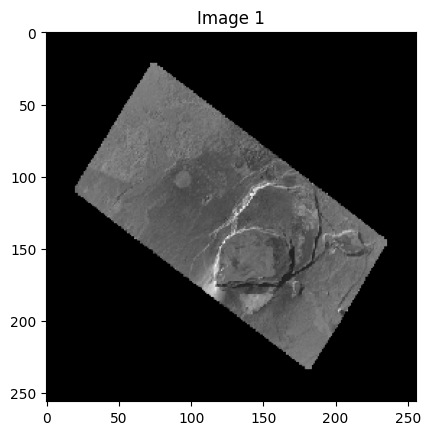

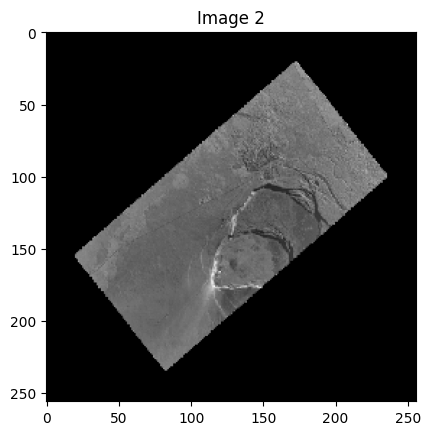

In [5]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Image {i}")
    plt.show()

In [6]:
print(images.shape)
print(images.min(), images.max())

(10, 256, 256)
0 192


In [7]:
images = images.astype(np.float32)

In [8]:
images_log = np.log1p(np.abs(images))

In [9]:
images_norm = (images_log - np.mean(images_log)) / np.std(images_log)

In [10]:
images_norm = images_norm[..., np.newaxis]

print(images_norm.shape)

(10, 256, 256, 1)


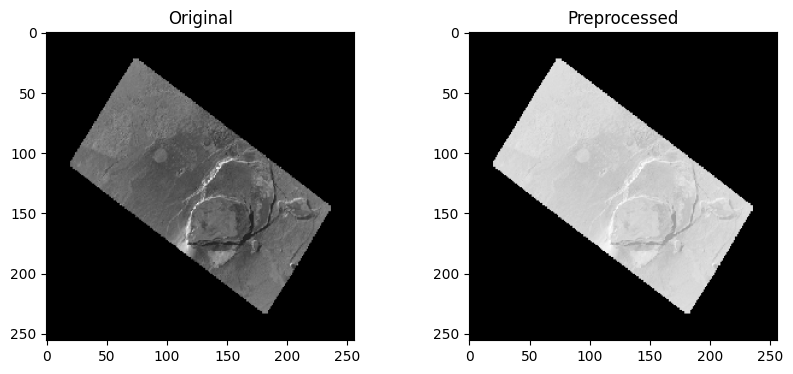

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(images[0], cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(images_norm[0].squeeze(), cmap='gray')
plt.title("Preprocessed")

plt.show()

In [12]:
#METHOD 1: First vs Last Difference (Simple & Powerful

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# First and last image
img1 = images_norm[0]
img2 = images_norm[-1]

# Absolute difference
diff = np.abs(img2 - img1)

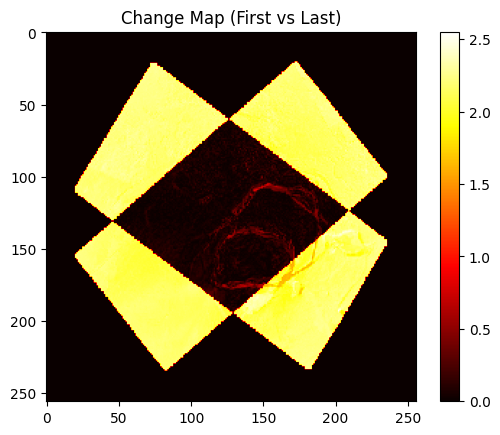

In [14]:
plt.imshow(diff.squeeze(), cmap='hot')
plt.title("Change Map (First vs Last)")
plt.colorbar()
plt.show()

In [15]:
#METHOD 2: Temporal Variance (STRONGER 🔥)

In [16]:
variance_map = np.var(images_norm, axis=0)

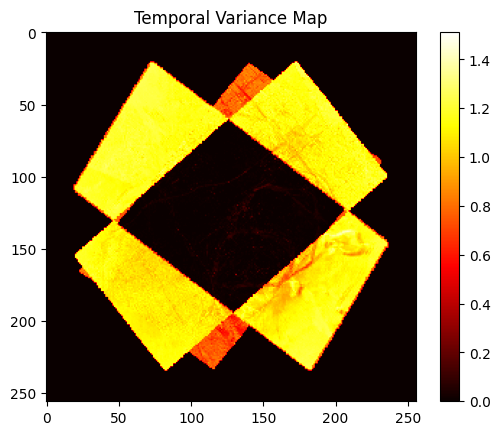

In [17]:
plt.imshow(variance_map.squeeze(), cmap='hot')
plt.title("Temporal Variance Map")
plt.colorbar()
plt.show()

In [20]:
#METHOD 3: Change Score (Global Metric)
change_score = diff.mean()
variance_score = variance_map.mean()

print("Change Score:", change_score)
print("Variance Score:", variance_score)

Change Score: 0.6944004
Variance Score: 0.37953526


In [21]:
#METHOD 4: Threshold-based Change Mask
threshold = np.mean(diff) + np.std(diff)

change_mask = diff > threshold

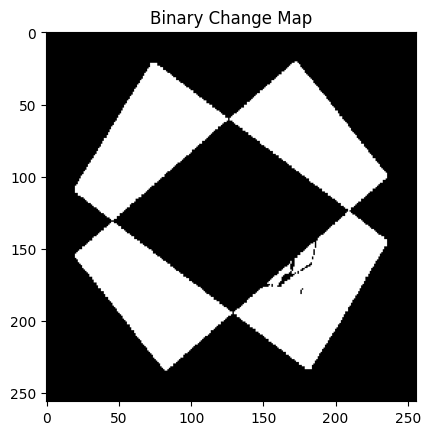

In [22]:
plt.imshow(change_mask.squeeze(), cmap='gray')
plt.title("Binary Change Map")
plt.show()

In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU Available: True
GPU Name: NVIDIA RTX A4000


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# during training
inputs = inputs.to(device)
labels = labels.to(device)

NameError: name 'model' is not defined

In [3]:
import torch
import torch.nn as nn

# create model
model = nn.Linear(10, 2)

# move to GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Model is on:", device)

Model is on: cuda


In [4]:
for inputs, labels in dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs)

NameError: name 'dataloader' is not defined